# ML Zoomcamp — Homework 2: Regression

**Module:** 02 — Regression  
**Dataset:** `car_fuel_efficiency.csv` — predict `fuel_efficiency_mpg`  
**Spec:** `Homework2_README.md` (or [GitHub source](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/cohorts/2025/02-regression/homework.md))

**Workflow.** Each question lives in its own section. Keep cells short and idempotent — re-running the notebook top-to-bottom should produce the same answers.

**Submission link:** <https://courses.datatalks.club/ml-zoomcamp-2025/homework/hw02>

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
RANDOM_SEED = 42

print(f"numpy {np.__version__} | pandas {pd.__version__}")

numpy 2.4.4 | pandas 3.0.2


In [4]:
# Load the dataset (sits next to this notebook)
DATA_PATH = "car_fuel_efficiency.csv"
FEATURES = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
    "fuel_efficiency_mpg",
]

df_raw = pd.read_csv(DATA_PATH)
df = df_raw[FEATURES].copy()
df.shape, df.columns.tolist()

((9704, 5),
 ['engine_displacement',
  'horsepower',
  'vehicle_weight',
  'model_year',
  'fuel_efficiency_mpg'])

## EDA
Look at the `fuel_efficiency_mpg` variable. Does it have a long tail?

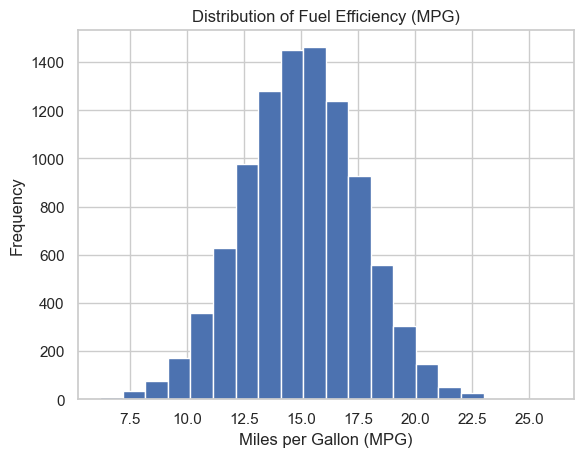

In [5]:
# TODO: histogram / describe() of fuel_efficiency_mpg, comment on the tail
df["fuel_efficiency_mpg"].hist(bins=20)
plt.xlabel("Miles per Gallon (MPG)")
plt.ylabel("Frequency")
plt.title("Distribution of Fuel Efficiency (MPG)")
plt.show()

Seems pretty simmetric to me...so I would say no tail

## Q1 — Which column has missing values?
Options: `engine_displacement`, `horsepower`, `vehicle_weight`, `model_year`

In [7]:
# TODO: df.isna().sum(), number of missing values and % of missing values per column
missing_values = df.isna().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})
print(missing_df)

                     Missing Values  Percentage
engine_displacement               0     0.00000
horsepower                      708     7.29596
vehicle_weight                    0     0.00000
model_year                        0     0.00000
fuel_efficiency_mpg               0     0.00000


horsepower has 708 missing values, which account 7.3% of the data

## Q2 — Median of `horsepower`
Options: 49, 99, 149, 199

In [10]:
# TODO: median of horsepower
df["horsepower"].describe()
#median_horsepower = df["horsepower"].median()
#print(f"Median Horsepower: {median_horsepower}")

count    8996.000000
mean      149.657292
std        29.879555
min        37.000000
25%       130.000000
50%       149.000000
75%       170.000000
max       271.000000
Name: horsepower, dtype: float64

Median is 149

## Prepare & split
Shuffle with seed `42`, split 60/20/20 train / val / test. Use the lecture's helper code.

Define helpers here (`prepare_X`, `train_linear_regression`, `train_linear_regression_reg`, `rmse`) so later cells can reuse them.

In [14]:
# TODO: implement split_data(df, seed) -> (df_train, df_val, df_test, y_train, y_val, y_test)
# TODO: implement train_linear_regression(X, y) -> (w0, w)
# TODO: implement train_linear_regression_reg(X, y, r) -> (w0, w)
# TODO: implement rmse(y, y_pred) -> float

test_size = 0.2
val_size = 0.2 
RANDOM_SEED = 42 

def prepare_data(df, target_col="fuel_efficiency_mpg", test_size=test_size, val_size=val_size, random_seed=RANDOM_SEED):
    # Shuffle the dataset
    df_shuffled = df.sample(frac=1, random_state=random_seed).reset_index(drop=True)
    
    # Split into features and target
    X = df_shuffled.drop(columns=[target_col])
    y = df_shuffled[target_col]
    
    # Calculate split indices
    total_samples = len(df)
    test_split_idx = int(total_samples * (1 - test_size))
    val_split_idx = int(test_split_idx * (1 - val_size))
    
    # Split the data
    X_train = X[:val_split_idx]
    y_train = y[:val_split_idx]
    
    X_val = X[val_split_idx:test_split_idx]
    y_val = y[val_split_idx:test_split_idx]
    
    X_test = X[test_split_idx:]
    y_test = y[test_split_idx:]
    
    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df)
print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")

Training set: (6210, 4), Validation set: (1553, 4), Test set: (1941, 4)


## Q3 — Fill missing with `0` vs. train-set mean
Train LR (no regularisation) on each fill strategy; compare val RMSE (rounded to 2 dp).

In [ ]:
# TODO: Q3

## Q4 — Regularised LR, find best `r`
Fill NAs with `0`. Try `r in [0, 0.01, 0.1, 1, 5, 10, 100]`. Round RMSE to 2 dp. Tie-break: smallest `r`.
Options: 0, 0.01, 1, 10, 100

In [ ]:
# TODO: Q4

## Q5 — Stability across seeds
Repeat split for seeds `0..9`, fill NAs with `0`, no regularisation. Compute `np.std` of val RMSEs, round to 3 dp.
Options: 0.001, 0.006, 0.060, 0.600

In [ ]:
# TODO: Q5

## Q6 — Final test RMSE
Seed `9`, combine train + val, fill NAs with `0`, train with `r = 0.001`. Report test RMSE.
Options: 0.15, 0.515, 5.15, 51.5

In [ ]:
# TODO: Q6

---
## Answers summary

| # | Question | Answer |
|---|----------|--------|
| 1 | Column with missing values | _TBD_ |
| 2 | Median of `horsepower` | _TBD_ |
| 3 | Fill 0 vs mean | _TBD_ |
| 4 | Best `r` | _TBD_ |
| 5 | Std of RMSEs across seeds | _TBD_ |
| 6 | Test RMSE (seed=9, r=0.001) | _TBD_ |